In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
class PaperTrader:
    """
    Paper trading engine — simulates live trading
    without real money. Tracks positions, cash,
    trades and equity curve.
    """
    def __init__(self, capital=100000,
                 max_drawdown_pct=0.15):
        self.initial_capital  = capital
        self.cash             = capital
        self.positions        = {}   # {ticker: shares}
        self.avg_cost         = {}   # {ticker: avg_cost}
        self.trades           = []   # trade log
        self.equity_curve     = []   # daily equity
        self.max_drawdown_pct = max_drawdown_pct
        self.peak_equity      = capital
        self.killed           = False  # kill switch

    def get_portfolio_value(self, current_prices):
        """Mark-to-market portfolio value."""
        holdings_value = sum(
            self.positions.get(t, 0) * current_prices.get(t, 0)
            for t in self.positions
        )
        return self.cash + holdings_value

    def execute(self, ticker, target_shares,
                price, date):
        """
        Execute a trade to reach target_shares.
        Positive = buy, negative = sell.
        """
        if self.killed:
            print(f"  KILL SWITCH ACTIVE — no trading")
            return

        current_shares = self.positions.get(ticker, 0)
        order_shares   = target_shares - current_shares

        if order_shares == 0:
            return

        cost      = order_shares * price
        cost_pct  = abs(order_shares) * price * 0.0006

        if order_shares > 0 and cost + cost_pct > self.cash:
            # Reduce order to fit available cash
            affordable = int(self.cash /
                             (price * 1.0006))
            order_shares = max(0, affordable)
            cost         = order_shares * price
            cost_pct     = order_shares * price * 0.0006

        if order_shares == 0:
            return

        # Update positions
        self.cash -= (cost + cost_pct)
        self.positions[ticker] = (current_shares +
                                   order_shares)

        # Remove zero positions
        if self.positions[ticker] == 0:
            del self.positions[ticker]

        # Log trade
        self.trades.append({
            "date"  : date,
            "ticker": ticker,
            "shares": order_shares,
            "price" : price,
            "cost"  : cost_pct,
            "action": "BUY" if order_shares > 0 else "SELL"
        })

        action = "BUY" if order_shares > 0 else "SELL"
        print(f"  {date} {action} {abs(order_shares)} "
              f"{ticker} @ ${price:.2f} "
              f"(cost: ${cost_pct:.2f})")

    def mark_to_market(self, date, current_prices):
        """Update equity curve and check kill switch."""
        portfolio_val = self.get_portfolio_value(
                            current_prices)
        self.equity_curve.append({
            "date"  : date,
            "equity": portfolio_val,
            "cash"  : self.cash
        })

        # Update peak and check drawdown
        if portfolio_val > self.peak_equity:
            self.peak_equity = portfolio_val
        drawdown = (portfolio_val - self.peak_equity) / \
                    self.peak_equity

        if drawdown < -self.max_drawdown_pct and \
           not self.killed:
            print(f"\n  *** KILL SWITCH TRIGGERED ***")
            print(f"  Drawdown {drawdown:.1%} exceeds "
                  f"limit {-self.max_drawdown_pct:.1%}")
            print(f"  Flattening all positions")
            self.killed = True

        return portfolio_val, drawdown

    def report(self):
        """Print portfolio summary."""
        eq = pd.DataFrame(self.equity_curve)
        if len(eq) == 0:
            print("No equity data yet")
            return

        final_equity = eq['equity'].iloc[-1]
        total_return = (final_equity /
                        self.initial_capital) - 1
        n_trades     = len(self.trades)

        print(f"\n{'='*50}")
        print(f"  PAPER TRADING REPORT")
        print(f"{'='*50}")
        print(f"  Initial capital : ${self.initial_capital:>12,.2f}")
        print(f"  Final equity    : ${final_equity:>12,.2f}")
        print(f"  Total return    : {total_return:>12.2%}")
        print(f"  Total trades    : {n_trades:>12}")
        print(f"  Cash remaining  : ${self.cash:>12,.2f}")
        print(f"  Kill switch     : {'TRIGGERED' if self.killed else 'OK':>12}")
        print(f"{'='*50}")

        if self.positions:
            print(f"\n  Current positions:")
            for t, s in self.positions.items():
                print(f"    {t}: {s} shares")

print("PaperTrader class ready")

PaperTrader class ready


In [3]:
# Load recent SPY data for simulation
df = yf.download("SPY", start="2023-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price  = df["Close"].squeeze()
sma50  = price.rolling(50).mean()
sma200 = price.rolling(200).mean()
rsi2   = compute_rsi(price, period=2)

# Initialise paper trader with $100k and 15% kill switch
pt = PaperTrader(capital=100000, max_drawdown_pct=0.15)

print("PAPER TRADING SIMULATION — SPY 2023")
print("=" * 55)

# Simulate day by day
for i in range(200, len(price)):
    date        = price.index[i].date()
    curr_price  = float(price.iloc[i])
    curr_prices = {"SPY": curr_price}

    # Generate signal (using yesterday's signal — no lookahead)
    in_uptrend  = price.iloc[i-1] > sma200.iloc[i-1]
    sma_long    = sma50.iloc[i-1] > sma200.iloc[i-1]
    rsi_oversold = rsi2.iloc[i-1] < 10

    # Combined signal
    if sma_long or (rsi_oversold and in_uptrend):
        target_position = 1  # fully invested
    else:
        target_position = 0  # flat

    # Convert to shares
    portfolio_val  = pt.get_portfolio_value(curr_prices)
    target_shares  = int(portfolio_val *
                         target_position / curr_price)
    current_shares = pt.positions.get("SPY", 0)

    # Execute if position changes
    if target_shares != current_shares and not pt.killed:
        pt.execute("SPY", target_shares,
                   curr_price, date)

    # Mark to market
    equity, dd = pt.mark_to_market(date, curr_prices)

# Print report
pt.report()

[*********************100%***********************]  1 of 1 completed

PAPER TRADING SIMULATION — SPY 2023
  2023-10-19 BUY 242 SPY @ $412.27 (cost: $59.86)

  PAPER TRADING REPORT
  Initial capital : $  100,000.00
  Final equity    : $  111,827.21
  Total return    :       11.83%
  Total trades    :            1
  Cash remaining  : $      170.51
  Kill switch     :           OK

  Current positions:
    SPY: 242 shares


[*********************100%***********************]  1 of 1 completed



  LIVE MONITORING DASHBOARD
  2026-06-25 11:57:09
  Portfolio Value : $  177,614.59
  Total Return    :       77.61%
  Peak Equity     : $  112,151.39
  Current Drawdown:       58.37%
  Realised Sharpe :         4.81
  Cash            : $      170.51

  POSITIONS:
    SPY       242 shares @ $  733.24 = $177,444.08

  ALERTS:
    All systems normal


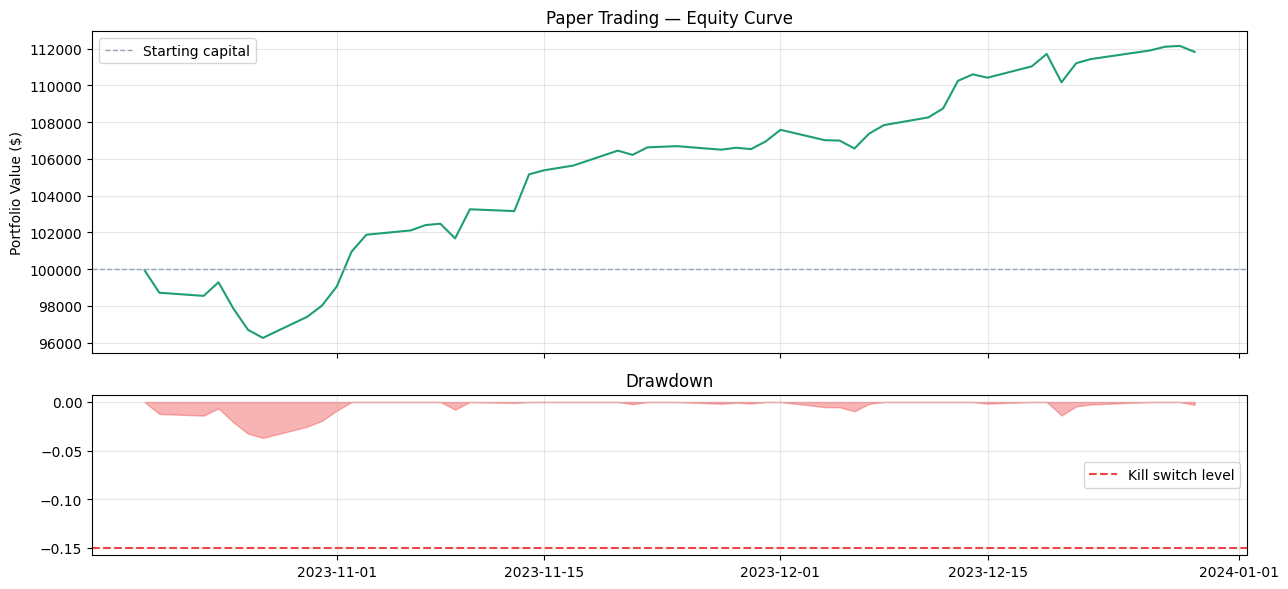

In [4]:
def monitoring_dashboard(paper_trader, current_prices):
    """
    Print live monitoring dashboard showing
    positions, P&L, drawdown and alerts.
    """
    eq_df = pd.DataFrame(paper_trader.equity_curve)
    if len(eq_df) == 0:
        print("No data yet")
        return

    current_equity = paper_trader.get_portfolio_value(
                         current_prices)
    total_return   = (current_equity /
                      paper_trader.initial_capital) - 1
    peak           = paper_trader.peak_equity
    drawdown       = (current_equity - peak) / peak

    # Rolling daily returns
    eq_df['daily_ret'] = eq_df['equity'].pct_change()
    avg_daily = eq_df['daily_ret'].mean()
    vol_daily = eq_df['daily_ret'].std()
    sharpe    = (avg_daily * 252 - 0.02) / \
                (vol_daily * np.sqrt(252)) \
                if vol_daily > 0 else 0

    print(f"\n{'='*55}")
    print(f"  LIVE MONITORING DASHBOARD")
    print(f"  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*55}")
    print(f"  Portfolio Value : ${current_equity:>12,.2f}")
    print(f"  Total Return    : {total_return:>12.2%}")
    print(f"  Peak Equity     : ${peak:>12,.2f}")
    print(f"  Current Drawdown: {drawdown:>12.2%}")
    print(f"  Realised Sharpe : {sharpe:>12.2f}")
    print(f"  Cash            : ${paper_trader.cash:>12,.2f}")
    print(f"{'='*55}")

    # Positions
    print(f"\n  POSITIONS:")
    if paper_trader.positions:
        for ticker, shares in paper_trader.positions.items():
            price  = current_prices.get(ticker, 0)
            value  = shares * price
            print(f"    {ticker:<6} {shares:>6} shares @ "
                  f"${price:>8.2f} = ${value:>10,.2f}")
    else:
        print(f"    FLAT — no open positions")

    # Alerts
    print(f"\n  ALERTS:")
    alerts = []
    if drawdown < -0.10:
        alerts.append(f"WARNING: Drawdown {drawdown:.1%} "
                      f"approaching kill switch")
    if paper_trader.killed:
        alerts.append("CRITICAL: Kill switch triggered")
    if abs(drawdown) < 0.01:
        alerts.append("INFO: Near high watermark")
    if not alerts:
        alerts.append("All systems normal")
    for a in alerts:
        print(f"    {a}")

    print(f"{'='*55}")

    # Plot equity curve
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6),
        gridspec_kw={'height_ratios': [2, 1]},
        sharex=True)

    ax1.plot(pd.to_datetime(eq_df['date']),
             eq_df['equity'], color='#1D9E75', lw=1.5)
    ax1.axhline(paper_trader.initial_capital,
                color='#94a3b8', lw=1, linestyle='--',
                label='Starting capital')
    ax1.set_title('Paper Trading — Equity Curve')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Drawdown
    eq_series = eq_df['equity']
    dd_series = (eq_series - eq_series.cummax()) / \
                 eq_series.cummax()
    ax2.fill_between(pd.to_datetime(eq_df['date']),
                     dd_series, 0,
                     color='#ef4444', alpha=0.4)
    ax2.axhline(-paper_trader.max_drawdown_pct,
                color='#ef4444', lw=1.5,
                linestyle='--', label='Kill switch level')
    ax2.set_title('Drawdown')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Get current SPY price
latest = yf.download("SPY", period="1d",
                      auto_adjust=True)
latest.columns = latest.columns.get_level_values(0)
current_spy = float(latest["Close"].iloc[-1])

monitoring_dashboard(pt, {"SPY": current_spy})